# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to evaluate how sole material, insole thickness, and fabric breathability affect the comfort of a running shoe, and to determine which combination of these factors produces the highest comfort rating.

2.  Specify the outcome variable and how it is measured.

The outcome variable is the **comfort rating**, which is measured on a scale from 1 to 10, where:
- 1 = very uncomfortable  
- 10 = very comfortable  

Each athlete runs for 30 minutes in the assigned shoe and provides a comfort score.

3.  Specify the independent variables. What lurking variables may be present?

The independent variables (treatment factors) are:

- Sole Material (A)
  - $(-)$: Standard EVA foam  
  - $(+)$: Advanced gel-infused foam  

- Insole Thickness (B)
  - $(-)$: 3 mm  
  - $(+)$: 6 mm  

- Fabric Breathability (C)
  - $(-)$: Standard woven fabric  
  - $(+)$: High-performance mesh fabric  

Possible lurking variables include:
- differences in athletes' foot shape or arch type  
- personal comfort preferences  
- fatigue or soreness levels  
- running style or pace  
- shoe fit  
- environmental conditions such as temperature

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

A full factorial design includes all possible combinations of the levels of the treatment factors.

A $2^k$ factorial design is a type of full factorial design where there are $k$ factors and each factor has exactly 2 levels.

In this experiment, there are 3 factors with 2 levels each, so this is a full $2^3$ factorial design with:

$$
2^3 = 8 \text{ treatment combinations}
$$

This design is preferred because it allows us to evaluate:
- all main effects  
- all two-way interactions  
- the three-way interaction  

This is important because the effect of one factor may depend on the level of another factor.

5.  State the sets of null and alternative hypotheses for this experiment.

We test hypotheses for main effects, two-way interactions, and the three-way interaction.

#### Main Effects

Sole Material (A):
$$
H_0: \mu_{A-} = \mu_{A+}
$$
$$
H_a: \mu_{A-} \ne \mu_{A+}
$$

Insole Thickness (B):
$$
H_0: \mu_{B-} = \mu_{B+}
$$
$$
H_a: \mu_{B-} \ne \mu_{B+}
$$

Breathability (C):
$$
H_0: \mu_{C-} = \mu_{C+}
$$
$$
H_a: \mu_{C-} \ne \mu_{C+}
$$

---

#### Two-Way Interactions

$A \times B$:
$$
H_0: \text{No interaction between A and B}
$$
$$
H_a: \text{Interaction exists between A and B}
$$

$A \times C$:
$$
H_0: \text{No interaction between A and C}
$$
$$
H_a: \text{Interaction exists between A and C}
$$

$B \times C$:
$$
H_0: \text{No interaction between B and C}
$$
$$
H_a: \text{Interaction exists between B and C}
$$

---

#### Three-Way Interaction

$A \times B \times C$:
$$
H_0: \text{No three-way interaction among A, B, and C}
$$
$$
H_a: \text{A three-way interaction exists among A, B, and C}
$$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

Exploratory analysis was conducted using summary statistics, boxplots, and interaction plots to understand how comfort ratings vary across the three factors: sole material, insole thickness, and breathability.

From the summary statistics and boxplots, there are clear differences across all three main factors. For sole material, shoes with Gel have a higher average comfort rating (9.0436) compared to EVA (7.0936), showing a noticeable increase in comfort. For insole thickness, the 6 mm insole (8.6958) has a higher mean comfort rating than the 3 mm insole (7.4415), indicating that thicker insoles are generally more comfortable. For breathability, the Woven condition (≈8.633) has a higher average comfort than Mesh (7.5042). This difference is visible in the plots, although it is not as consistent across all conditions and shows slightly higher variability.

The treatment-combination means further confirm these patterns. The highest mean comfort rating is observed for Gel + 6 mm + Woven (11.0280), while the lowest is for EVA + 3 mm + Mesh (6.3681). This large gap between combinations suggests that the factor levels do not produce equal comfort ratings and that certain combinations perform much better than others.

The boxplots also support these findings visually. Across all plots, the Gel groups tend to be higher than EVA, and the 6 mm groups tend to be higher than 3 mm. In particular, the difference between Woven and Mesh becomes more noticeable at higher thickness levels, especially within the Gel material.

The interaction plots provide additional insight into how factors work together. The plot for sole material × insole thickness shows nearly parallel lines, indicating little to no interaction between these two factors. The increase in comfort from 3 mm to 6 mm is very similar for both EVA and Gel, suggesting mostly independent effects.

The plot for sole material × breathability shows some difference in slopes. While Woven is higher than Mesh for both materials, the increase is larger for Gel than for EVA, suggesting a possible interaction, though not extremely strong.

The strongest interaction pattern appears in the insole thickness × breathability plot. The lines are clearly not parallel, and the increase in comfort from 3 mm to 6 mm is much larger for Woven than for Mesh. This indicates that the effect of thickness depends heavily on breathability, providing strong visual evidence of interaction between these two factors.

Overall, the exploratory analysis shows clear differences in comfort ratings across all three main factors and suggests that at least one interaction (especially between insole thickness and breathability) may be present. Based on these patterns, the results support the alternative hypotheses more strongly than the null hypotheses.

In [4]:
## Question 6 Code ##
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Check the structure of the data
print(df.info())
print(df.head())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   comfort           24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
  sole_material insole_thickness breathability   comfort
0           EVA              3mm         Woven  6.373546
1           EVA              3mm         Woven  7.183643
2           EVA              3mm         Woven  6.164371
3           EVA              3mm          Mesh  7.595281
4           EVA              3mm          Mesh  6.329508
Index(['sole_material', 'insole_thickness', 'breathability', 'comfort'], dtype='object')


In [5]:
# Mean and standard deviation for Sole Material
sole_stats = df.groupby("sole_material")["comfort"].agg(["mean", "std"])
print("Summary statistics for Sole Material:")
print(sole_stats)

print("\n")

# Mean and standard deviation for Insole Thickness
thickness_stats = df.groupby("insole_thickness")["comfort"].agg(["mean", "std"])
print("Summary statistics for Insole Thickness:")
print(thickness_stats)

print("\n")

# Mean and standard deviation for Breathability
breath_stats = df.groupby("breathability")["comfort"].agg(["mean", "std"])
print("Summary statistics for Breathability:")
print(breath_stats)

Summary statistics for Sole Material:
                   mean       std
sole_material                    
EVA            7.093638  1.076122
Gel            9.043596  1.545309


Summary statistics for Insole Thickness:
                      mean       std
insole_thickness                    
3mm               7.441465  1.387030
6mm               8.695768  1.684642


Summary statistics for Breathability:
                   mean       std
breathability                    
Mesh           7.504218  1.272221
Woven          8.633016  1.818369


In [6]:
# Mean and standard deviation for all treatment combinations
combo_stats = df.groupby(
    ["sole_material", "insole_thickness", "breathability"]
)["comfort"].agg(["mean", "std"])

print("Summary statistics for all treatment combinations:")
print(combo_stats)

Summary statistics for all treatment combinations:
                                                   mean       std
sole_material insole_thickness breathability                     
EVA           3mm              Mesh            6.368107  1.208337
                               Woven           6.573854  0.538350
              6mm              Mesh            7.032079  0.916897
                               Woven           8.400512  0.127263
Gel           3mm              Mesh            8.294237  0.562753
                               Woven           8.529663  1.670397
              6mm              Mesh            8.322450  1.439997
                               Woven          11.028033  0.166786


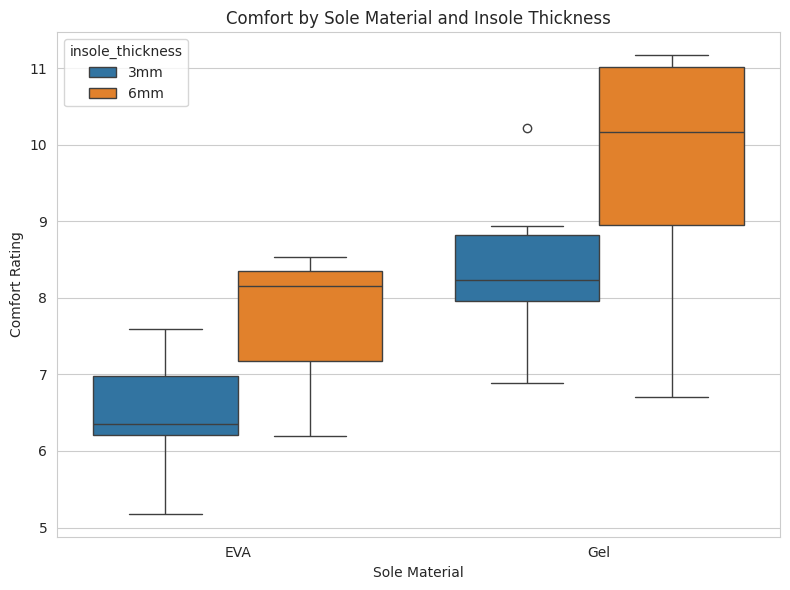

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Boxplot: Sole Material with Insole Thickness as hue
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="sole_material", y="comfort", hue="insole_thickness")
plt.title("Comfort by Sole Material and Insole Thickness")
plt.xlabel("Sole Material")
plt.ylabel("Comfort Rating")
plt.tight_layout()
plt.show()

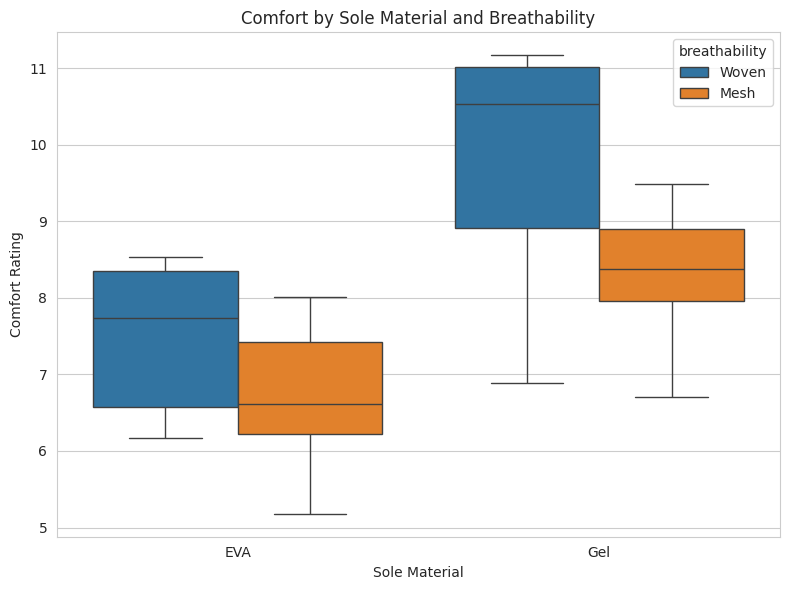

In [9]:
# Boxplot: Sole Material with Breathability as hue
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="sole_material", y="comfort", hue="breathability")
plt.title("Comfort by Sole Material and Breathability")
plt.xlabel("Sole Material")
plt.ylabel("Comfort Rating")
plt.tight_layout()
plt.show()

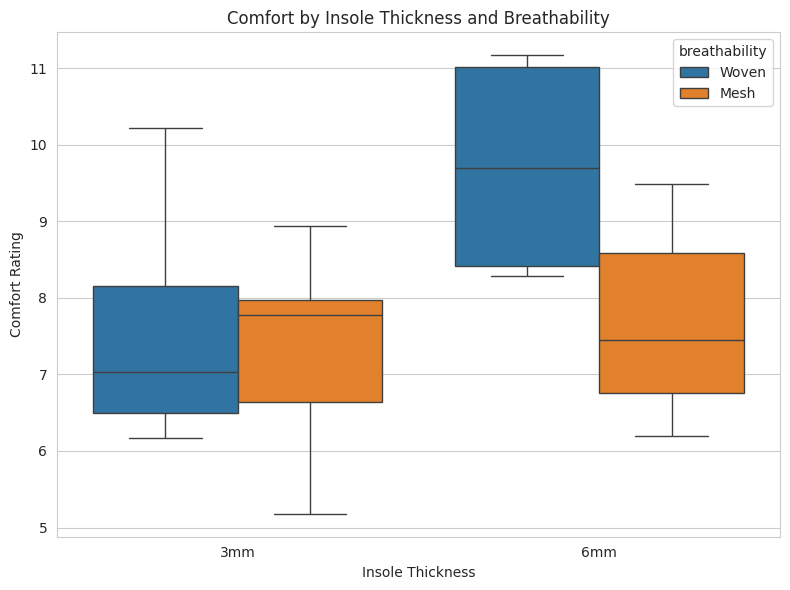

In [10]:
# Boxplot: Insole Thickness with Breathability as hue
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="insole_thickness", y="comfort", hue="breathability")
plt.title("Comfort by Insole Thickness and Breathability")
plt.xlabel("Insole Thickness")
plt.ylabel("Comfort Rating")
plt.tight_layout()
plt.show()

In [11]:
# Means for two-way interactions
ab_means = df.groupby(["sole_material", "insole_thickness"])["comfort"].mean().reset_index()
ac_means = df.groupby(["sole_material", "breathability"])["comfort"].mean().reset_index()
bc_means = df.groupby(["insole_thickness", "breathability"])["comfort"].mean().reset_index()

print("A x B means:")
print(ab_means)

print("\nA x C means:")
print(ac_means)

print("\nB x C means:")
print(bc_means)

A x B means:
  sole_material insole_thickness   comfort
0           EVA              3mm  6.470980
1           EVA              6mm  7.716295
2           Gel              3mm  8.411950
3           Gel              6mm  9.675242

A x C means:
  sole_material breathability   comfort
0           EVA          Mesh  6.700093
1           EVA         Woven  7.487183
2           Gel          Mesh  8.308344
3           Gel         Woven  9.778848

B x C means:
  insole_thickness breathability   comfort
0              3mm          Mesh  7.331172
1              3mm         Woven  7.551759
2              6mm          Mesh  7.677264
3              6mm         Woven  9.714272


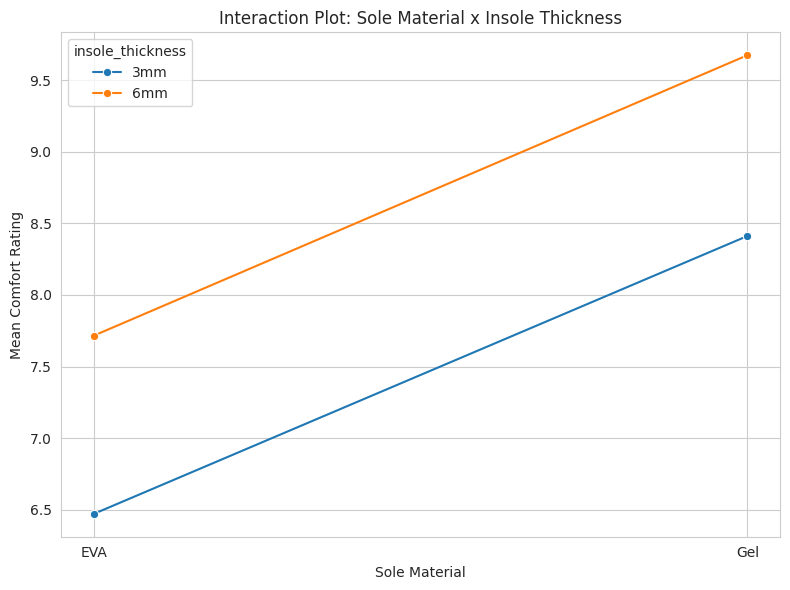

In [13]:
sns.set_style("whitegrid")

# Interaction Plot: Sole Material x Insole Thickness
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=ab_means,
    x="sole_material",
    y="comfort",
    hue="insole_thickness",
    marker="o"
)
plt.title("Interaction Plot: Sole Material x Insole Thickness")
plt.xlabel("Sole Material")
plt.ylabel("Mean Comfort Rating")
plt.tight_layout()
plt.show()

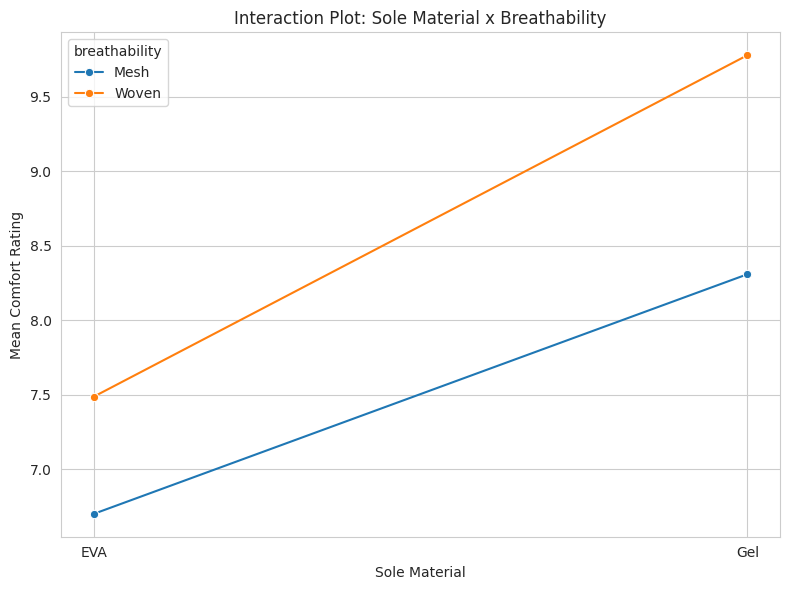

In [15]:
# Interaction Plot: Sole Material x Breathability
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=ac_means,
    x="sole_material",
    y="comfort",
    hue="breathability",
    marker="o"
)
plt.title("Interaction Plot: Sole Material x Breathability")
plt.xlabel("Sole Material")
plt.ylabel("Mean Comfort Rating")
plt.tight_layout()
plt.show()

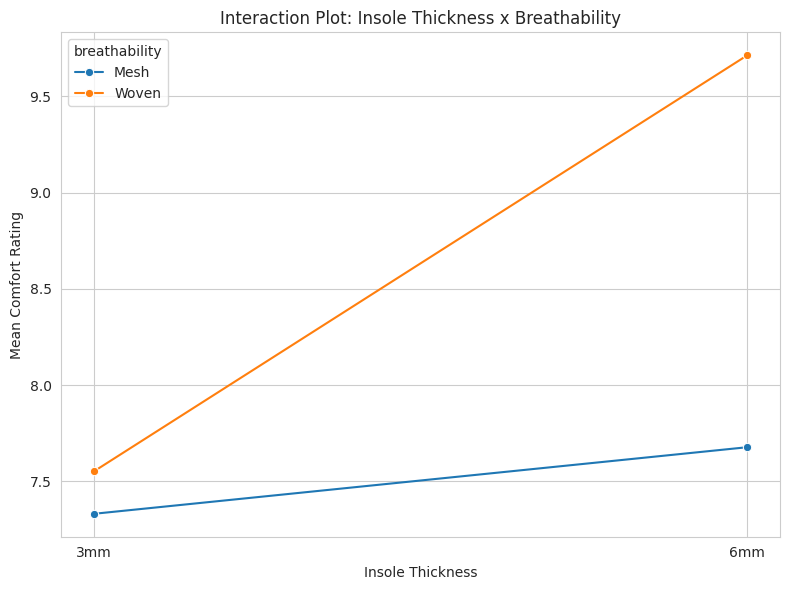

In [14]:
# Interaction Plot: Insole Thickness x Breathability
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=bc_means,
    x="insole_thickness",
    y="comfort",
    hue="breathability",
    marker="o"
)
plt.title("Interaction Plot: Insole Thickness x Breathability")
plt.xlabel("Insole Thickness")
plt.ylabel("Mean Comfort Rating")
plt.tight_layout()
plt.show()

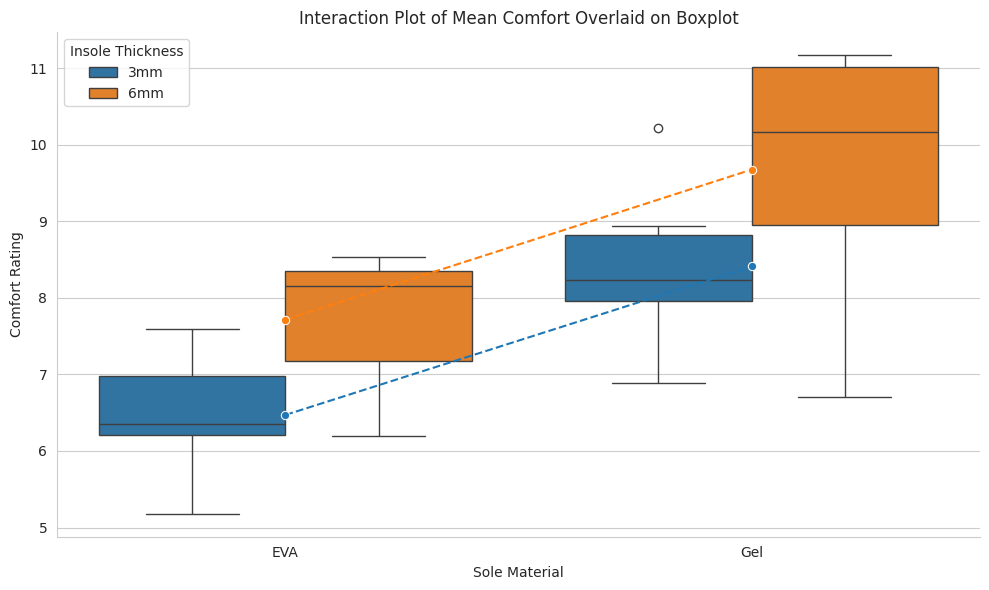

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sole_material",
    y="comfort",
    hue="insole_thickness",
    dodge=True,
    ax=ax,
    zorder=2
)

sns.lineplot(
    data=df,
    x="sole_material",
    y="comfort",
    hue="insole_thickness",
    estimator="mean",
    marker="o",
    linestyle="--",
    errorbar=None,
    ax=ax,
    zorder=3
)

ax.set_title("Interaction Plot of Mean Comfort Overlaid on Boxplot")
ax.set_xlabel("Sole Material")
ax.set_ylabel("Comfort Rating")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Insole Thickness")

sns.despine()
plt.tight_layout()
plt.show()

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?

To assess the normality assumption, both a visual method (QQ plot) and a formal test (Shapiro–Wilk test) were used on the model residuals.

From the QQ plot, most of the residual points lie close to the straight reference line. There are slight deviations at the extreme ends (tails), but no strong curvature or systematic pattern is observed. This indicates that the residuals are approximately normally distributed, with only minor departures at the tails, which is expected in small samples.

From the Shapiro–Wilk test, the test statistic is 0.9595 with a p-value of 0.4291. Since the p-value is greater than 0.05, we fail to reject the null hypothesis of normality. This means there is no statistical evidence suggesting that the residuals deviate from a normal distribution.

Overall, both the visual and testing methods are consistent. The QQ plot shows only small deviations, and the Shapiro–Wilk test is not significant. Therefore, we have sufficient evidence to conclude that the normality assumption is reasonably satisfied for this model.

                            OLS Regression Results                            
Dep. Variable:                comfort   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     6.755
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           0.000786
Time:                        01:45:13   Log-Likelihood:                -28.908
No. Observations:                  24   AIC:                             73.82
Df Residuals:                      16   BIC:                             83.24
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

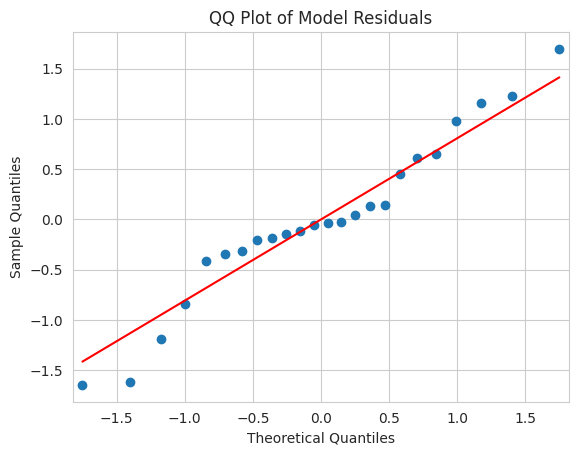


Shapiro-Wilk Test for Normality
Statistic: 0.9595
p-value: 0.4291
Fail to reject H0: the residuals appear to be approximately normally distributed.


In [17]:
## Question 7 Code ##
# Question 7: Full factorial ANOVA model + normality check

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# Load the data
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Fit full factorial ANOVA model
mod = ols("comfort ~ sole_material * insole_thickness * breathability", data=df).fit()

# Show model summary if needed
print(mod.summary())

# Type III ANOVA table
anova_table = sm.stats.anova_lm(mod, typ=3)
anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")
print("\nFull Factorial ANOVA Table:")
print(anova_table)

# -------------------------------
# Normality assumption
# -------------------------------

# Residuals
residuals = mod.resid

# QQ plot
sm.qqplot(residuals, line="s")
plt.title("QQ Plot of Model Residuals")
plt.show()

# Shapiro-Wilk test
sw_stat, sw_p = stats.shapiro(residuals)
print("\nShapiro-Wilk Test for Normality")
print(f"Statistic: {sw_stat:.4f}")
print(f"p-value: {sw_p:.4f}")

if sw_p < 0.05:
    print("Reject H0: the residuals do not appear to be normally distributed.")
else:
    print("Fail to reject H0: the residuals appear to be approximately normally distributed.")


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?

The constant variance assumption was evaluated using both a residuals vs fitted values plot and the Breusch–Pagan test.

From the residuals vs fitted values plot, the residuals are scattered randomly around zero with no clear systematic pattern. There is no visible funnel shape or increasing/decreasing spread as fitted values increase. The spread of residuals appears relatively similar across lower, middle, and higher fitted values, which suggests that the variance is approximately constant.

From the Breusch–Pagan test, the test statistic is 11.9361 with a p-value of 0.1027. Since the p-value is greater than 0.05, we fail to reject the null hypothesis of constant variance. This means there is no statistical evidence of heteroscedasticity.

Overall, both the visual method and the formal test are consistent. The residual plot does not show any clear pattern in variance, and the Breusch–Pagan test is not significant. Therefore, the constant variance assumption appears to be reasonably satisfied for this model.

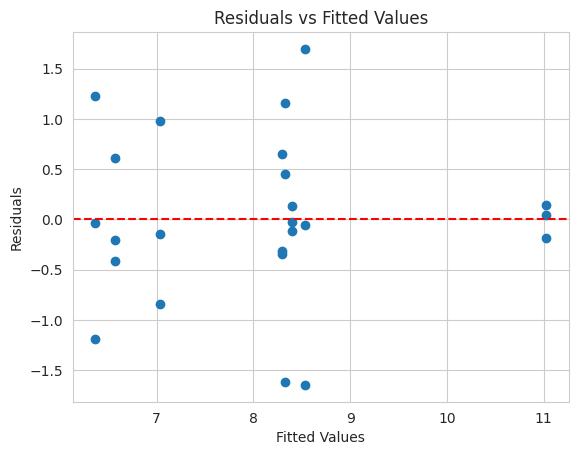


Breusch-Pagan Test
Statistic: 11.9361
p-value: 0.1027
Fail to reject H0: variance appears to be constant.


In [18]:
## Question 8 Code ##
# -------------------------------
# Constant variance (homoscedasticity)
# -------------------------------

import statsmodels.stats.api as sms

# Residuals and fitted values
fitted = mod.fittedvalues
residuals = mod.resid

# Residuals vs Fitted plot
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Breusch-Pagan test
bp_test = sms.het_breuschpagan(residuals, mod.model.exog)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("\nBreusch-Pagan Test")
print(f"Statistic: {bp_stat:.4f}")
print(f"p-value: {bp_pvalue:.4f}")

if bp_pvalue < 0.05:
    print("Reject H0: evidence of non-constant variance (heteroscedasticity).")
else:
    print("Fail to reject H0: variance appears to be constant.")


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [ ]:
## Question 9 Code ##


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [ ]:
## Question 10 Code ##


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.

3.  Specify the independent variables. What lurking variables may be present?

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Question 7 Code ##


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [ ]:
## Question 8 Code ##


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [ ]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?